In [52]:
import pandas as pd
import ast

# Load the dataset
df = pd.read_csv('labelled_merged_dataset.csv')

# Create 'IsChain' based on repeating Titles
title_counts = df['Title'].value_counts()
df['IsChain'] = df['Title'].apply(lambda x: 1 if title_counts[x] > 1 else 0)

# Create 'tag_count' from the Categories column
import ast
def parse_categories(x):
    try:
        return len(ast.literal_eval(x)) if pd.notnull(x) else 0
    except:
        return 0
df['tag_count'] = df['Categories'].apply(parse_categories)

# Convert Rating to binary
df['RatingBinary'] = df['Rating'].map({'Good': 1, 'Bad': 0})

df.head()

,Title,Category,Rating,Address,Categories,ZCTA,NAME,Median_Income,Population,Males_20yrs_age,Males_30yrs_age,Males_60yrs_age,Females_20yrs_age,Females_30yrs_age,Females_60yrs_age,Asian,American,Hispanic_or_Latino,IsChain,tag_count,RatingBinary
0,Dairy Queen Grill & Chill,Fast food restaurant,Bad,"Dairy Queen Grill & Chill, 3143 US-280, Alexan...","['Fast food restaurant', 'Ice cream shop']",35010,ZCTA5 35010,46730,20406,414,658,409,246,636,434,107,1864,899,1,2,0
1,Jake's Restaurant,American restaurant,Good,"Jake's Restaurant, 16 Broad St, Alexander City...",['American restaurant'],35010,ZCTA5 35010,46730,20406,414,658,409,246,636,434,107,1864,899,1,1,1
2,Carib Kitchen,Caribbean restaurant,Good,"Carib Kitchen, 68 Broad St, Alexander City, AL...",['Caribbean restaurant'],35010,ZCTA5 35010,46730,20406,414,658,409,246,636,434,107,1864,899,0,1,1
3,Cazadores Mexican Restaurant,Mexican restaurant,Good,"Cazadores Mexican Restaurant, 910 Cherokee Rd,...",['Mexican restaurant'],35010,ZCTA5 35010,46730,20406,414,658,409,246,636,434,107,1864,899,1,1,1
4,La Posada Mexican Grill,Mexican restaurant,Bad,"La Posada Mexican Grill, 3714 US-280, Alexande...","['Mexican restaurant', 'Latin American restaur...",35010,ZCTA5 35010,46730,20406,414,658,409,246,636,434,107,1864,899,1,2,0


In [53]:
from sklearn.preprocessing import StandardScaler

# Combine all feature columns into one dataframe
features_df = df[['IsChain', 'tag_count','Median_Income','Population','Asian','American','Hispanic_or_Latino']]

# Standardize the 'tag_count' feature (so that it has mean 0, std 1)
scaler = StandardScaler()
features_df[['tag_count']] = scaler.fit_transform(features_df[['tag_count']])

# Final feature matrix X and target vector y
X = features_df.values
y = df['RatingBinary'].values

<ipython-input-53-69ab3eb01ead>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features_df[['tag_count']] = scaler.fit_transform(features_df[['tag_count']])


In [54]:
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

# Desired columns to display
selected_columns = ['Median_Income', 'Population', 'Asian', 'American', 'Hispanic_or_Latino', 'IsChain', 'tag_count', 'Intercept']

# Train-test split and add intercept
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_train_b = np.hstack([np.ones((X_train.shape[0], 1)), X_train])
X_test_b  = np.hstack([np.ones((X_test.shape[0], 1)), X_test])

# Create column names: Intercept + feature names
all_columns = ['Intercept'] + list(features_df.columns)

# Create DataFrames using correct column names
train_df_full = pd.DataFrame(X_train_b, columns=all_columns)
test_df_full = pd.DataFrame(X_test_b, columns=all_columns)

# Select and display only desired columns
train_df = train_df_full[selected_columns]
test_df = test_df_full[selected_columns]

print("Training Data Sample (80%):\n", train_df.head(), "\n")
print("Test Data Sample (20%): \n", test_df.head())


Training Data Sample (80%):
    Median_Income  Population   Asian  American  Hispanic_or_Latino  IsChain  tag_count  Intercept
0        81449.0      7438.0   222.0     480.0               760.0      0.0  -0.885783        1.0
1        79726.0     74005.0  5670.0    1050.0             25533.0      1.0   0.017960        1.0
2        58290.0      6034.0    80.0      70.0               112.0      1.0  -0.885783        1.0
3        51927.0     56696.0   384.0     524.0             28720.0      0.0   0.017960        1.0
4        44675.0     29357.0   121.0    2512.0               952.0      1.0   1.373576        1.0 

Test Data Sample (20%): 
    Median_Income  Population   Asian  American  Hispanic_or_Latino  IsChain  tag_count  Intercept
0        91847.0     38107.0  3109.0     585.0              4643.0      1.0   0.017960        1.0
1        68831.0     38265.0  2393.0    1846.0              7595.0      0.0   0.921704        1.0
2        53760.0     13484.0   134.0     393.0               

In [55]:
# Initialize weights for each feature (including intercept) to 0
w = np.zeros(X_train_b.shape[1])

# Sigmoid function
def sigmoid(z):
    z = np.array(z, dtype=np.float64)
    return 1 / (1 + np.exp(-z))

# Gradient descent parameters
learning_rate = 0.5
num_iterations = 200

cost_history = []  # to store cost at each iteration
m = X_train_b.shape[0]  # number of training examples
epsilon = 1e-5         # small constant to avoid log(0)

# Ensure correct data types
X_train_b = np.asarray(X_train_b, dtype=np.float64)
y_train = np.asarray(y_train, dtype=np.float64)
w = np.asarray(w, dtype=np.float64)

# Run gradient descent
for i in range(num_iterations):
    z = X_train_b.dot(w)
    h = sigmoid(z)
    cost = -(1/m) * (np.dot(y_train, np.log(h + epsilon)) + np.dot((1 - y_train), np.log(1 - h + epsilon)))
    cost_history.append(cost)
    gradient = (1/m) * X_train_b.T.dot(h - y_train)
    w -= learning_rate * gradient

# After training, compute test probabilities and predictions
probabilities = sigmoid(X_test_b.dot(w))
y_pred = (probabilities >= 0.5).astype(int)

# Print learned weights with corresponding feature names
feature_names = ['Intercept'] + list(features_df.columns)
weights_df = pd.DataFrame({'Feature': feature_names, 'Weight': w})
print("\n Learned Weights:")
print(weights_df.sort_values(by='Weight', ascending=False).head(10))  # top 10 positive weights
print(weights_df.sort_values(by='Weight').head(10))                   # top 10 negative weights

# Show sample predictions
print("\n Sample Predicted Probabilities and Classes:")
for i in range(5):
    print(f"Sample {i+1}: Probability = {probabilities[i]:.4f}, Predicted = {y_pred[i]}, Actual = {y_test[i]}")

<ipython-input-55-84a948e38363>:7: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))



 Learned Weights:
              Feature        Weight
3       Median_Income  18929.527812
7  Hispanic_or_Latino   2242.329120
0           Intercept     -0.029543
1             IsChain     -7.633125
2           tag_count     -8.031733
6            American  -1969.780989
5               Asian  -4382.248688
4          Population -17081.249411
              Feature        Weight
4          Population -17081.249411
5               Asian  -4382.248688
6            American  -1969.780989
2           tag_count     -8.031733
1             IsChain     -7.633125
0           Intercept     -0.029543
7  Hispanic_or_Latino   2242.329120
3       Median_Income  18929.527812

 Sample Predicted Probabilities and Classes:
Sample 1: Probability = 1.0000, Predicted = 1, Actual = 1
Sample 2: Probability = 1.0000, Predicted = 1, Actual = 0
Sample 3: Probability = 1.0000, Predicted = 1, Actual = 0
Sample 4: Probability = 1.0000, Predicted = 1, Actual = 1
Sample 5: Probability = 1.0000, Predicted = 1, Actual =

<ipython-input-55-84a948e38363>:7: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))


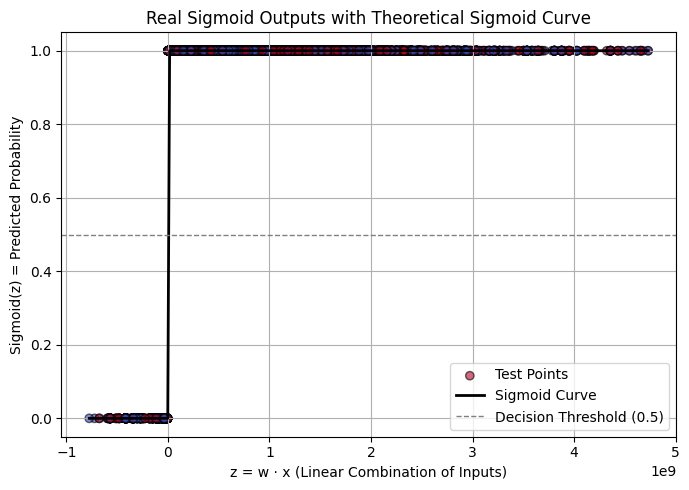

In [56]:
import matplotlib.pyplot as plt
import numpy as np

# Compute z values from your test data
z_test = X_test_b.dot(w)
sigmoid_output = sigmoid(z_test)

# Create a smooth sigmoid curve for comparison
z_smooth = np.linspace(min(z_test)-1, max(z_test)+1, 300)
sigmoid_smooth = sigmoid(z_smooth)

# Plot real sigmoid outputs (scatter) + sigmoid curve (line)
plt.figure(figsize=(7, 5))
plt.scatter(z_test, sigmoid_output, c=y_test, cmap='coolwarm', alpha=0.6, edgecolor='k', label='Test Points')
plt.plot(z_smooth, sigmoid_smooth, color='black', linewidth=2, label='Sigmoid Curve')

# Plot formatting
plt.title("Real Sigmoid Outputs with Theoretical Sigmoid Curve")
plt.xlabel("z = w · x (Linear Combination of Inputs)")
plt.ylabel("Sigmoid(z) = Predicted Probability")
plt.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Decision Threshold (0.5)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [57]:
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, roc_curve

# Compute evaluation metrics
cm = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
auc_score = roc_auc_score(y_test, probabilities)

print("Accuracy:", accuracy)
print("AUC:", auc_score)
print("Confusion Matrix:\n", cm)

Accuracy: 0.49515600250488084
AUC: 0.5029986914658732
Confusion Matrix:
 [[  309 13486]
 [  219 13133]]


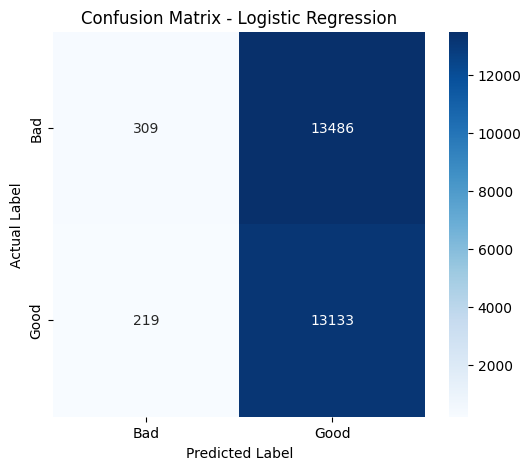

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Bad", "Good"],
            yticklabels=["Bad", "Good"])
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

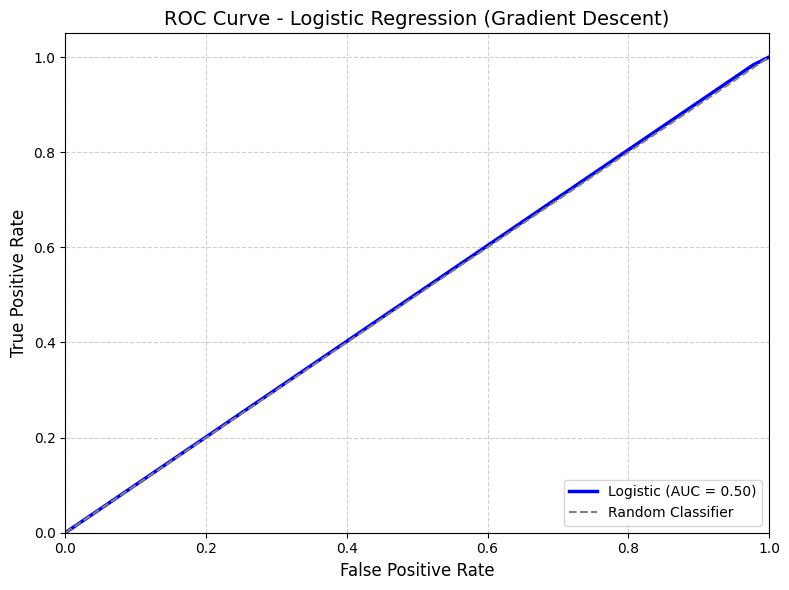

In [59]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, probabilities)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve with styling
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2.5, label=f"Logistic (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1.5, label='Random Classifier')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curve - Logistic Regression (Gradient Descent)", fontsize=14)
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
